# About this notebook

This notebook is a corrected version of the original baseline feedforward neural network.

The original implementation (`BaselineFFN_original.ipynb`) was used in the report as a reference baseline model. However, it contains a mismatch between the output layer and loss function, where a sigmoid activation was applied before using `BCEWithLogitsLoss`.

This notebook removes the sigmoid layer and outputs raw logits, ensuring compatibility with the loss function. In addition, it includes Batch Normalization, Dropout, and weight decay for improved training stability and regularization.

This version was used primarily for analysis and comparison with other models (across the notebooks), while the original baseline was retained to provide a consistent reference point.

# Imports

In [1]:
# Matplotlib
import matplotlib.pyplot as plt
# Numpy
import numpy as np
# Torch
import torch
import torchvision
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Normalize
import pandas as pd

In [2]:
# Use GPU if available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Data

In [ ]:
"Download the dataset from Kaggle - setup Kaggle API first"

# !kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0




  0%|          | 0.00/66.0M [00:00<?, ?B/s]
100%|██████████| 66.0M/66.0M [00:00<00:00, 1.43GB/s]


In [ ]:
"Unzip the downloaded file"

# import zipfile

# with zipfile.ZipFile("data/creditcardfraud.zip", "r") as zip_ref:
#     zip_ref.extractall("data")

In [3]:
df = pd.read_csv('./data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('Class', axis=1).values
y = df['Class'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).to(device)
y_test = torch.FloatTensor(y_test).to(device)

# Calculate class weights to handle imbalance
n_samples = len(y_train)
n_fraud = (y_train == 1).sum().item()
n_normal = (y_train == 0).sum().item()

class_weight_normal = n_samples / (2 * n_normal)
class_weight_fraud = n_samples / (2 * n_fraud)

print(f"Total samples: {n_samples}")
print(f"Normal transactions: {n_normal}")
print(f"Fraudulent transactions: {n_fraud}")


Total samples: 227845
Normal transactions: 227451
Fraudulent transactions: 394


## Create DataLoader

In [5]:
# Custom Dataset class
class FraudDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Split training set into train and validation (75-25 split of the 80%)
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Create datasets
train_dataset = FraudDataset(X_train_split, y_train_split)
val_dataset = FraudDataset(X_val, y_val)
test_dataset = FraudDataset(X_test, y_test)

# DataLoader configuration
BATCH_SIZE = 2048
NUM_WORKERS = 0

# Create DataLoaders
train_dataloader = torch.utils.data.DataLoader(train_dataset, \
                                               batch_size=BATCH_SIZE, \
                                               shuffle=True, \
                                               num_workers=NUM_WORKERS)

val_dataloader = torch.utils.data.DataLoader(val_dataset, \
                                             batch_size=BATCH_SIZE, \
                                             shuffle=False, \
                                             num_workers=NUM_WORKERS)

test_dataloader = torch.utils.data.DataLoader(test_dataset, \
                                              batch_size=BATCH_SIZE, \
                                              shuffle=False, \
                                              num_workers=NUM_WORKERS)

print(f"Train DataLoader: {len(train_dataloader)} batches")
print(f"Val DataLoader: {len(val_dataloader)} batches")
print(f"Test DataLoader: {len(test_dataloader)} batches")


Train DataLoader: 84 batches
Val DataLoader: 28 batches
Test DataLoader: 28 batches


In [6]:
# Test DataLoader by iterating through a few batches
print("Sample batches from training data:\n")

for batch_number, (inputs, outputs) in enumerate(train_dataloader):
    print("---")
    print(f"Batch number: {batch_number}")
    print(f"Inputs shape: {inputs.shape}")
    print(f"Outputs shape: {outputs.shape}")
    
    if batch_number == 2:  # Show first 3 batches
        break


Sample batches from training data:

---
Batch number: 0
Inputs shape: torch.Size([2048, 30])
Outputs shape: torch.Size([2048])
---
Batch number: 1
Inputs shape: torch.Size([2048, 30])
Outputs shape: torch.Size([2048])
---
Batch number: 2
Inputs shape: torch.Size([2048, 30])
Outputs shape: torch.Size([2048])


# Model

In [7]:
import torch.nn as nn

class FraudDetectionNet(nn.Module):
    def __init__(self, input_features=30):
        super(FraudDetectionNet, self).__init__()
        
        self.fc1 = nn.Linear(input_features, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(32, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        return x

# Initialize model
model = FraudDetectionNet(input_features=30).to(device)
print(model)


FraudDetectionNet(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


## Training Setup

In [8]:
# Loss function with class weights
pos_weight = torch.tensor([class_weight_fraud / class_weight_normal]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print("Loss Function: Binary Cross-Entropy with class weighting")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Positive weight (fraud): {pos_weight.item():.4f}")


Loss Function: Binary Cross-Entropy with class weighting
Optimizer: Adam (lr=0.001)
Positive weight (fraud): 577.2868


# Training Loop

In [9]:
# Training function
def trainer(model, train_loader, val_loader, num_epochs=20, learning_rate=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # Display progress
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    
    return train_losses, val_losses

# Train the model
print("Starting training...\n")
train_losses, val_losses = trainer(model, train_dataloader, val_dataloader, num_epochs=20)
print("\nTraining complete!")


Starting training...

Epoch [1/20], Train Loss: 0.9730, Val Loss: 0.7386
Epoch [2/20], Train Loss: 0.7067, Val Loss: 0.5890
Epoch [3/20], Train Loss: 0.5775, Val Loss: 0.4891
Epoch [4/20], Train Loss: 0.4435, Val Loss: 0.4111
Epoch [5/20], Train Loss: 0.3857, Val Loss: 0.3684
Epoch [6/20], Train Loss: 0.3520, Val Loss: 0.3492
Epoch [7/20], Train Loss: 0.3276, Val Loss: 0.3441
Epoch [8/20], Train Loss: 0.3427, Val Loss: 0.3416
Epoch [9/20], Train Loss: 0.2890, Val Loss: 0.3362
Epoch [10/20], Train Loss: 0.2768, Val Loss: 0.3380
Epoch [11/20], Train Loss: 0.2836, Val Loss: 0.3393
Epoch [12/20], Train Loss: 0.2728, Val Loss: 0.3311
Epoch [13/20], Train Loss: 0.2528, Val Loss: 0.3206
Epoch [14/20], Train Loss: 0.2743, Val Loss: 0.3348
Epoch [15/20], Train Loss: 0.2478, Val Loss: 0.3407
Epoch [16/20], Train Loss: 0.2558, Val Loss: 0.3504
Epoch [17/20], Train Loss: 0.2653, Val Loss: 0.3361
Epoch [18/20], Train Loss: 0.2401, Val Loss: 0.3395
Epoch [19/20], Train Loss: 0.2279, Val Loss: 0.3506

# Evaluation & Testing

For fraud detection, we evaluate using metrics beyond accuracy since the data is imbalanced:
- **Precision**: Of predicted frauds, how many are actually frauds?
- **Recall**: Of actual frauds, how many did we catch?
- **F1 Score**: Balance between precision and recall
- **ROC-AUC**: Area under the ROC curve - measures discriminative ability

In [23]:
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Evaluation function
def evaluate(model, dataloader, device):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            
            # Forward pass
            outputs = model(inputs)
            probs = outputs.cpu().numpy()
            preds = (probs > 0.5).astype(int).flatten()
            
            all_probs.extend(probs.flatten())
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # Calculate metrics
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp
    }

# Evaluate on test set
test_metrics = evaluate(model, test_dataloader, device)

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1 Score:  {test_metrics['f1']:.4f}")
print(f"ROC-AUC:   {test_metrics['roc_auc']:.4f}")
print(f"PR-AUC:   {test_metrics['pr_auc']:.4f}")
print("\nConfusion Matrix:")
print(f"True Negatives:  {test_metrics['tn']}")
print(f"False Positives: {test_metrics['fp']}")
print(f"False Negatives: {test_metrics['fn']}")
print(f"True Positives:  {test_metrics['tp']}")


TEST SET RESULTS
Precision: 0.0767
Recall:    0.9082
F1 Score:  0.1415
ROC-AUC:   0.9853
PR-AUC:   0.7486

Confusion Matrix:
True Negatives:  55793
False Positives: 1071
False Negatives: 9
True Positives:  89


# Visualization

Loss graph and confusion matrix

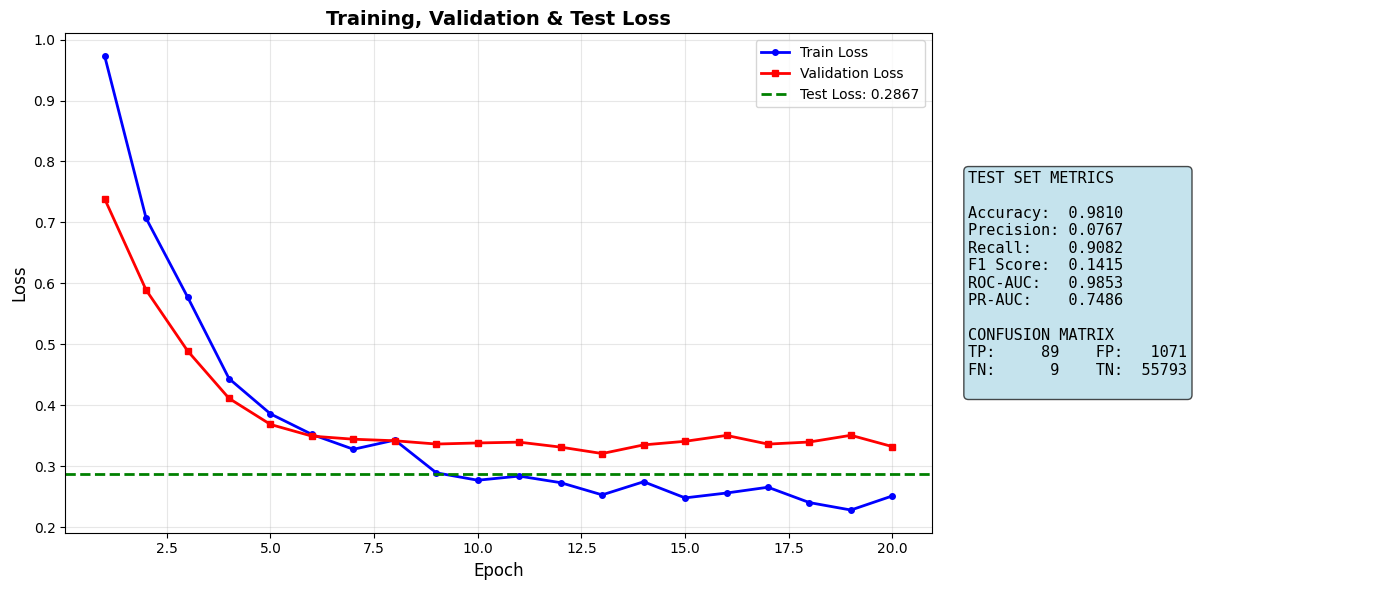

In [19]:
# Calculate test loss
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

test_loss /= len(test_dataloader)

# Create figure with 2 panels (left bigger than right)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})

# ===== LEFT: Loss Curves =====
ax1 = axes[0]
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2, marker='o', markersize=4)
ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)
ax1.axhline(y=test_loss, color='g', linestyle='--', label=f'Test Loss: {test_loss:.4f}', linewidth=2)

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training, Validation & Test Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ===== RIGHT: Metrics + Confusion Matrix =====
ax2 = axes[1]
ax2.axis('off')

accuracy = (test_metrics['tp'] + test_metrics['tn']) / (
    test_metrics['tp'] + test_metrics['tn'] + test_metrics['fp'] + test_metrics['fn']
)

metrics_text = f"""TEST SET METRICS

Accuracy:  {accuracy:.4f}
Precision: {test_metrics['precision']:.4f}
Recall:    {test_metrics['recall']:.4f}
F1 Score:  {test_metrics['f1']:.4f}
ROC-AUC:   {test_metrics['roc_auc']:.4f}
PR-AUC:    {test_metrics['pr_auc']:.4f}

CONFUSION MATRIX
TP: {test_metrics['tp']:>6}    FP: {test_metrics['fp']:>6}
FN: {test_metrics['fn']:>6}    TN: {test_metrics['tn']:>6}
"""

ax2.text(0.05, 0.5, metrics_text,
         fontsize=11,
         family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()


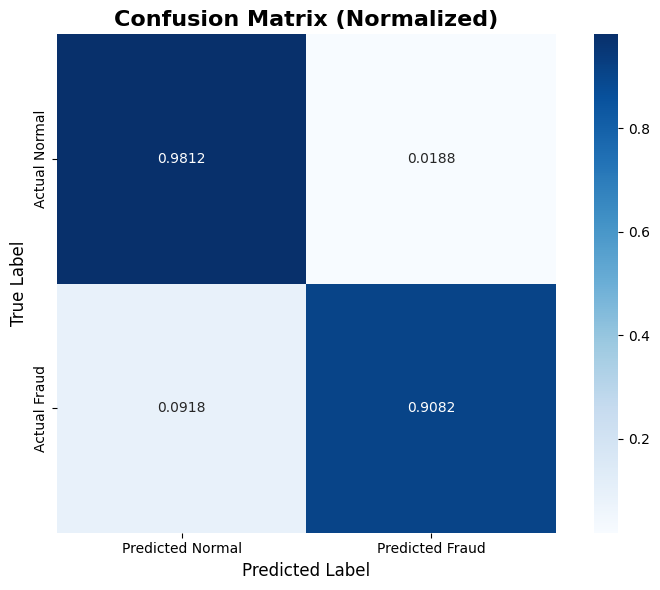

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Build confusion matrix from your metrics
cm = np.array([
    [test_metrics['tn'], test_metrics['fp']],
    [test_metrics['fn'], test_metrics['tp']]
])

# Normalize
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Fraud'],
    yticklabels=['Actual Normal', 'Actual Fraud'],
    cbar=True,
    square=True
)

plt.title('Confusion Matrix (Normalized)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()


# Analysis of results
| Metric    |  Value |
| --------- | -----: |
| Precision | 0.0767 |
| Recall    | 0.9082 |
| F1 Score  | 0.1415 |
| ROC-AUC   | 0.9853 |
| PR-AUC    | 0.7486 |

- The model achieves a very high **recall** of `0.9082` (~91%), which means that it successfully detects most fraud cases.
- However, the **precision** is very low at `0.0767` (~8%), indicating a large number of false positives. This means that only 7% of predicted frauds are actually frauds.
- Because of this, our F1 score is low (~14%) due to the imbalance between precision and recall.

- The **ROC-AUC score** is very high (`0.9853`), suggesting that the model is able to distinguish between fraudulent and normal transactions well overall. However, ROC-AUC can be misleading in imbalanced datasets because it is heavily influenced by the large number of true negatives.

- The **PR-AUC score (`0.7468`) provides a more meaningful evaluation** for this task. Unlike ROC-AUC, PR-AUC focuses on the trade-off between precision and recall, which is more relevant for fraud detection where the minority class (fraud) is of primary interest. The relatively moderate PR-AUC reflects the model’s strong recall but weak precision, giving a more realistic picture of its performance.

With these results, we can observe that our model is very aggressive in predicting fraud and tries not to miss fraud cases. Because of this, we accept many false positives. While this behavior may be acceptable in safety-critical systems where missing fraud is costly, in real-world applications it would negatively impact user experience as many normal users would be incorrectly flagged.

Possible improvements:
- Add autoencoder (detect anomalies)
- Use weighted classifier (handle imbalance better)
- Finetuning:
    - Adjust threshold (reduce false positives to improve precision)
    - Tune class weights (try not to overweigh fraud class)
    - Use PR-AUC for better evaluation in imbalanced datasets